In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve, roc_auc_score, precision_recall_curve,auc
import matplotlib.pyplot as plt
import lightgbm as lgb


pd.set_option('display.max_columns', None)

### Load Model Input Data

In [2]:
df=pd.read_csv("../Model_Input_Data/Model_Input_Data.csv")
print(df.shape)
df.head()

(5410, 36)


,Provider,PotentialFraud,IP_Claim_Count,IP_Benf_Count,Avg_IP_InscClaimAmtReimbursed,Avg_IP_DeductibleAmtPaid,Avg_IP_Number_of_Days_in_Hospital,Avg_IP_Number_of_Days_in_Hospital.1,Avg_IP_Number_of_Days_in_Hospital.2,Avg_IP_Number_of_Days_in_Hospital.3,OP_Claim_Count,OP_Benf_Count,Avg_OP_InscClaimAmtReimbursed,Avg_OP_DeductibleAmtPaid,Avg_OP_Number_of_Days_in_Hospital,Avg_OP_Number_of_Days_in_Hospital.1,Avg_OP_Number_of_Days_in_Hospital.2,Total_Beneficiaries,RenalDisease_Count,Alzheimer_Count,HeartFailure_Count,KidneyDisease_Count,Cancer_Count,Pulmonary_Count,Depression_Count,Diabetes_Count,IschemicHeart_Count,Osteoporosis_Count,RheumatoidArthritis_Count,Stroke_Count,Avg_PartA_Months,Avg_PartB_Months_Mode,Avg_IP_Reimbursement,Avg_IP_Deductible,Avg_OP_Reimbursement,Avg_OP_Deductible
0,PRV51001,0,5,5,19400.000000,1068.0,0.0,0.0,6.0,0.0,20,19,382.000000,0.000000,0.0,1.0,0.0,24,8,10,6,7,19,15,15,4,2,18,16,19,12,12,18047.916667,890.000000,2537.500000,474.916667
1,PRV51003,1,62,53,9241.935484,1068.0,3.0,3.0,9.0,1.0,70,66,466.714286,1.000000,0.0,1.0,0.0,117,22,73,47,65,107,84,70,30,18,89,85,108,12,12,6814.017094,822.632479,2490.598291,664.529915
2,PRV51004,0,0,0,0.000000,0.0,0.0,0.0,0.0,0.0,149,138,350.134228,2.080537,0.0,1.0,0.0,138,20,78,56,91,122,101,78,42,40,95,97,122,12,12,4596.739130,454.144928,2095.144928,600.869565
3,PRV51005,1,0,0,0.000000,0.0,0.0,0.0,0.0,0.0,1165,495,241.124464,3.175966,0.0,1.0,0.0,495,79,330,232,317,436,390,311,181,148,353,368,456,12,12,3717.232323,398.698990,1798.808081,475.965657
4,PRV51007,0,3,3,6333.333333,1068.0,4.0,4.0,6.0,0.0,69,56,213.188406,0.869565,0.0,1.0,0.0,58,9,37,28,41,52,46,37,22,18,41,42,49,12,12,3109.655172,423.517241,1497.241379,430.689655


In [3]:
df.PotentialFraud.value_counts()

PotentialFraud
0    4904
1     506
Name: count, dtype: int64

Here The data was Imbalanced.

### Checking Correlation Coefficent

- build a correlation matrix.
- identify Higly correlated variables.

In [4]:
corr_matrix=df.iloc[:,1:].corr()
corr_matrix.head()

,PotentialFraud,IP_Claim_Count,IP_Benf_Count,Avg_IP_InscClaimAmtReimbursed,Avg_IP_DeductibleAmtPaid,Avg_IP_Number_of_Days_in_Hospital,Avg_IP_Number_of_Days_in_Hospital.1,Avg_IP_Number_of_Days_in_Hospital.2,Avg_IP_Number_of_Days_in_Hospital.3,OP_Claim_Count,OP_Benf_Count,Avg_OP_InscClaimAmtReimbursed,Avg_OP_DeductibleAmtPaid,Avg_OP_Number_of_Days_in_Hospital,Avg_OP_Number_of_Days_in_Hospital.1,Avg_OP_Number_of_Days_in_Hospital.2,Total_Beneficiaries,RenalDisease_Count,Alzheimer_Count,HeartFailure_Count,KidneyDisease_Count,Cancer_Count,Pulmonary_Count,Depression_Count,Diabetes_Count,IschemicHeart_Count,Osteoporosis_Count,RheumatoidArthritis_Count,Stroke_Count,Avg_PartA_Months,Avg_PartB_Months_Mode,Avg_IP_Reimbursement,Avg_IP_Deductible,Avg_OP_Reimbursement,Avg_OP_Deductible
PotentialFraud,1.000000,0.525393,0.522256,0.307556,0.319855,0.156278,0.157271,0.332043,0.203341,0.335803,0.340550,0.046770,0.041701,-0.005206,-0.058295,0.042329,0.393531,0.409965,0.386035,0.376435,0.375876,0.391582,0.381486,0.387190,0.375898,0.369433,0.390565,0.388635,0.389683,0.009770,0.008369,0.127398,0.119897,-0.015204,-0.031547
IP_Claim_Count,0.525393,1.000000,0.997492,0.327985,0.398766,0.223728,0.224221,0.418265,0.228004,0.208758,0.276037,0.049353,0.041827,-0.003967,-0.059130,0.049632,0.391992,0.443241,0.367057,0.346287,0.347629,0.385222,0.358068,0.370984,0.336251,0.325412,0.383660,0.379031,0.382209,0.009087,0.007868,0.165848,0.183794,-0.023449,-0.028603
IP_Benf_Count,0.522256,0.997492,1.000000,0.336416,0.409007,0.229987,0.230475,0.428677,0.231378,0.208244,0.278841,0.047527,0.040143,-0.004631,-0.062674,0.048281,0.395842,0.448558,0.370378,0.349185,0.350732,0.388839,0.361502,0.374276,0.338844,0.328001,0.387186,0.382511,0.386015,0.009265,0.008031,0.170824,0.189412,-0.023422,-0.028680
Avg_IP_InscClaimAmtReimbursed,0.307556,0.327985,0.336416,1.000000,0.839577,0.672207,0.671091,0.827822,0.578765,0.022452,0.039578,0.001402,-0.002840,-0.027280,-0.189112,0.015028,0.081826,0.103559,0.072955,0.063288,0.064599,0.079234,0.069923,0.074579,0.061251,0.057874,0.079036,0.077457,0.078331,0.005905,0.010255,0.478656,0.411210,-0.007450,-0.026045
Avg_IP_DeductibleAmtPaid,0.319855,0.398766,0.409007,0.839577,1.000000,0.661765,0.662139,0.976286,0.566851,0.028770,0.052258,-0.001592,-0.005470,-0.033019,-0.217772,0.017184,0.103420,0.129415,0.092288,0.081232,0.082823,0.100502,0.088882,0.094274,0.077895,0.074164,0.099966,0.097892,0.099275,-0.000936,0.003250,0.396898,0.433707,-0.029665,-0.042322


In [5]:
cols = corr_matrix.columns
corr_matrix['check'] = corr_matrix.apply(lambda row : [c for c in cols if 0.8<=abs(row[c])<1 ])

In [6]:
#corr_matrix[['check']]

### Train, Test Split

In [7]:
X_var = df.drop(columns = ['Provider','PotentialFraud'] )
y_var = df['PotentialFraud']

x_train,x_test,y_train,y_test = train_test_split(X_var,y_var,test_size = 0.2, stratify = y_var, random_state = 42)


In [8]:
print(x_train.shape)
print(x_test.shape)

(4328, 34)
(1082, 34)


In [9]:
print(y_train.value_counts())

PotentialFraud
0    3923
1     405
Name: count, dtype: int64


In [10]:
print(y_test.value_counts())

PotentialFraud
0    981
1    101
Name: count, dtype: int64


### Training LightGbm Regression Model

In [ ]:
lgb_estimate = lgb.LGBMClassifier(n_estimators= 70,
                                max_depth = 5,
                                n_leaves = 12,
                                learning_rate = 0.05,
                                random_state = 42,
                                verbosity = -1)
                        

lgb_estimate.fit(x_train,y_train)
y_pred = lgb_estimate.predict(x_test)
y_prob = lgb_estimate.predict_proba(x_test)[:, 1]
#acc_score = accuracy_score(y_test,y_pred)
print("*****Classification Rport********")
print(classification_report(y_test,y_pred))
print("**** Confusion Matrix ***********")
print(confusion_matrix(y_test,y_pred))

*****Classification Rport********
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       981
           1       0.78      0.57      0.66       101

    accuracy                           0.95      1082
   macro avg       0.87      0.78      0.82      1082
weighted avg       0.94      0.95      0.94      1082

**** Confusion Matrix ***********
[[965  16]
 [ 43  58]]


In [13]:
Train_score = accuracy_score(y_train,lgb_estimate.predict(x_train))
Test_score = accuracy_score(y_test,y_pred)
print("Train_score: ", Train_score)
print("Test_score: ", Test_score)
print("over_fiting: ", round((Train_score - Test_score)*100,3))

Train_score:  0.9572550831792976
Test_score:  0.9454713493530499
over_fiting:  1.178


### ROC and PR Curves

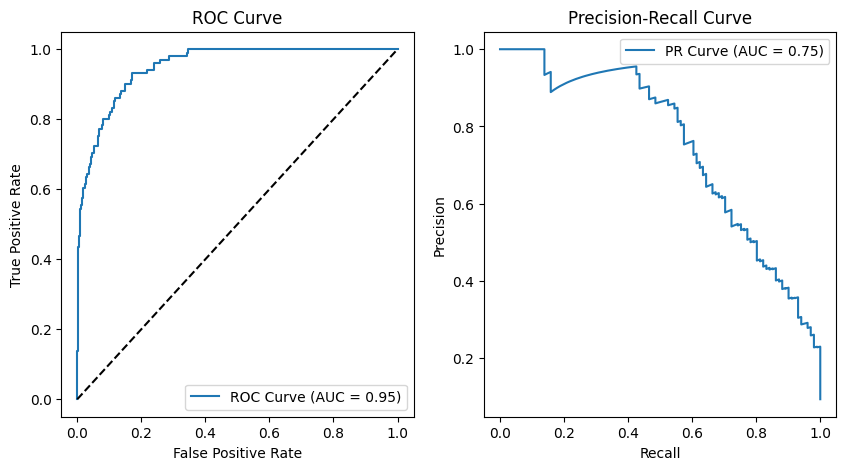

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

# 5. Plot ROC Curve
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# 6. Plot PR Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()